# 👩‍💻 Comparing Sparse and Dense Text Representations in Practice

## 📋 Overview
This activity invites you to delve into the realm of sparse and dense text representations, providing hands-on experience in comparing their effectiveness in various NLP tasks. Through this exploration, you'll understand how these representations impact machine learning model performance and discover the nuanced ways in which each method addresses language complexity.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- ✅ Implement and compare sparse text representations (Bag-of-Words, TF-IDF)
- ✅ Evaluate dense text representations using pre-trained embeddings
- ✅ Use text representations in classification tasks and analyze their impact on model performance

## Task 1: Data Preparation

**Context:** Proper data preparation is essential for implementing text representations.

**Steps:**

1. Starter code has been provided, including text data to use for this lab and has been loaded into a DataFrame.
2. Preprocess the text data by implementing tokenization, stopword removal, and lemmatization or stemming.

In [1]:
# Task 1: Data Preparation
# Required Imports
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import torch
from transformers import AutoModel, AutoTokenizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK resources (run once)
print("Downloading NLTK resources...")
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    nltk.download('punkt_tab')
    print("NLTK resources downloaded successfully.")
except Exception as e:
    print(f"Error downloading NLTK resources: {e}")
    print("Please ensure you have an internet connection or try running nltk.download() manually.")

# Define the data
texts = [
    "This movie is fantastic and I love it.",
    "The acting was great but the plot was weak.",
    "A terrible film, completely boring.",
    "I hated every minute of this production.",
    "Wonderful cinematography and compelling story.",
    "Bad script and poor direction.",
    "An absolute masterpiece, highly recommend.",
    "Utterly disappointing experience.",
    "Enjoyed it thoroughly, a real gem.",
    "Skip this one, it's a waste of time.",
    "The food was delicious and the service was excellent.",
    "Didn't like the atmosphere, too noisy.",
    "A truly unique and enjoyable experience.",
    "The product broke after only a week.",
    "Highly satisfied with my purchase.",
    "The customer support was unhelpful.",
    "What a fantastic performance!",
    "Quite boring, nothing special.",
    "Loved the vibrant colors and design.",
    "The instructions were unclear and confusing.",
    "Would definitely visit again.",
    "Overpriced for what you get.",
    "A pleasant surprise, much better than expected.",
    "Poor quality materials used.",
    "Seamless transaction and fast delivery.",
    "The ending was very predictable.",
    "Outstanding craftsmanship.",
    "Left feeling disappointed.",
    "So happy with the results!",
    "Could have been much better."
]
# Simple sentiment labels (1: positive, 0: negative/neutral)
labels = [
    1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]

# Create a DataFrame
df = pd.DataFrame({'text': texts, 'label': labels})
print("Original Data:")
print(df)
print(f"\nTotal number of examples: {len(df)}")

# Prepare data
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)
print("\nProcessed Data (first 5 rows):")
display(df.head())
print()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['processed_text'], df['label'], test_size=0.3, random_state=42, stratify=df['label'])

print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Train set label distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test set label distribution:\n{y_test.value_counts(normalize=True)}")

[nltk_data] Downloading package punkt_tab to /home/jovyan/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK resources downloaded successfully.
Original Data:
                                                 text  label
0              This movie is fantastic and I love it.      1
1         The acting was great but the plot was weak.      0
2                 A terrible film, completely boring.      0
3            I hated every minute of this production.      0
4      Wonderful cinematography and compelling story.      1
5                      Bad script and poor direction.      0
6          An absolute masterpiece, highly recommend.      1
7                   Utterly disappointing experience.      0
8                  Enjoyed it thoroughly, a real gem.      1
9                Skip this one, it's a waste of time.      0
10  The food was delicious and the service was exc...      1
11             Didn't like the atmosphere, too noisy.      0
12           A truly unique and enjoyable experience.      1
13               The product broke after only a week.      0
14                 Highly sati

,text,label,processed_text
0,This movie is fantastic and I love it.,1,movie fantastic love
1,The acting was great but the plot was weak.,0,acting great plot weak
2,"A terrible film, completely boring.",0,terrible film completely boring
3,I hated every minute of this production.,0,hated every minute production
4,Wonderful cinematography and compelling story.,1,wonderful cinematography compelling story




Train set size: 21
Test set size: 9
Train set label distribution:
0    0.52381
1    0.47619
Name: label, dtype: float64
Test set label distribution:
0    0.555556
1    0.444444
Name: label, dtype: float64


**💡 Tip:** Use `nltk` for tokenization, stopword removal, and lemmatization.

**⚙️ Test Your Work:**

- Print the preprocessed version of the first 5 text entries.

**Expected output:** Cleaned and standardized text ready for further processing.

## Task 2: Implementing Sparse Representations

**Context:** Sparse representations like Bag-of-Words (BoW) and TF-IDF convert text data into numerical form for analysis.

**Steps:**

1. Use the Bag-of-Words (BoW) approach to convert your text data into a sparse representation.
2. Visualize this representation to understand how text is transformed into numerical data.
3. Apply the TF-IDF technique to enhance the BoW representation.
4. Analyze the changes and note any patterns in term weighting and importance.

In [2]:
# Task 2: Implementing Sparse Representations

# Bag-of-Words (BoW)
vectorizer_bow = CountVectorizer()
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)
print("\n--- Bag-of-Words ---")
print("Vocabulary size:", len(vectorizer_bow.vocabulary_))
print("Train BoW matrix shape:", X_train_bow.shape)
print("Test BoW matrix shape:", X_test_bow.shape)


--- Bag-of-Words ---
Vocabulary size: 66
Train BoW matrix shape: (21, 66)
Test BoW matrix shape: (9, 66)


In [3]:
# TF-IDF
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)
print("\n--- TF-IDF ---")
print("Vocabulary size:", len(vectorizer_tfidf.vocabulary_))
print("Train TF-IDF matrix shape:", X_train_tfidf.shape)
print("Test TF-IDF matrix shape:", X_test_tfidf.shape)


--- TF-IDF ---
Vocabulary size: 66
Train TF-IDF matrix shape: (21, 66)
Test TF-IDF matrix shape: (9, 66)


**💡 Tip:** Use `CountVectorizer` for BoW and `TfidfVectorizer` for TF-IDF.

**⚙️ Test Your Work:**

- Print the shape and vocabulary size of the BoW and TF-IDF matrix.

**Expected output:** Information about the transformed data including matrix shapes and vocabulary sizes.

## Task 3: Exploring Dense Representations

**Context:** Dense representations like embeddings capture context and semantics in text data.

**Steps:**

1. Adopt a pre-trained embedding model from Hugging Face or similar repository to convert your text into dense vector representations.
2. Focus on how context and semantics are captured in these embeddings.
3. Use visualization tools like t-SNE or PCA to plot the dense representations.

In [4]:
# Task 3: Exploring Dense Representations

# Function to get embeddings
def get_embeddings(texts):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**encoded_input)
    # Mean pooling to get a single vector representation for each sentence
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    return sentence_embeddings.numpy()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] # First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# Using Pre-trained Embeddings (Sentence Transformers via Hugging Face)
# Load model and tokenizer
model_name = 'sentence-transformers/all-MiniLM-L6-v2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

X_train_dense = get_embeddings(X_train.tolist())
X_test_dense = get_embeddings(X_test.tolist())
print("\n--- Dense Embeddings ---")
print("Train Dense matrix shape:", X_train_dense.shape)
print("Test Dense matrix shape:", X_test_dense.shape)

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]


--- Dense Embeddings ---
Train Dense matrix shape: (21, 384)
Test Dense matrix shape: (9, 384)


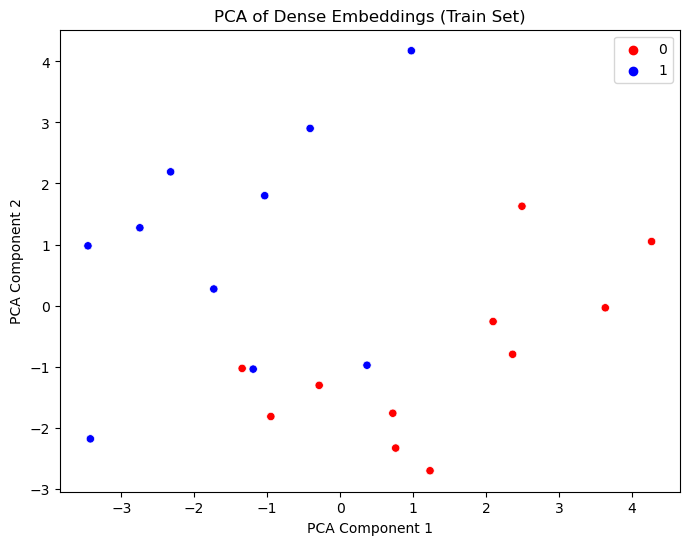

In [5]:
# Note: The dimension (768 for MiniLM) is fixed, unlike sparse representations.

# Visualize Dense Representations (using PCA)
# Reduce dimensionality for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_dense)
plt.figure(figsize=(8, 6))

# Use the original index from the split to map labels correctly
train_indices = X_train.index
colors = ['red' if label == 0 else 'blue' for label in y_train]
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train.tolist(), palette=['red', 'blue'], legend='full')
plt.title('PCA of Dense Embeddings (Train Set)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

**💡 Tip:** Use `AutoModel` and `AutoTokenizer` from the `transformers` library.

**⚙️ Test Your Work:**

- Plot the dense representations using PCA showing clusters based on original labels.

**Expected output:** A visual representation of dense embeddings showing clusters of semantically similar texts.

## Task 4: Comparing Representations in a Classification Task

**Context:** Comparing text representations in a classification task helps understand their impact on model performance.

**Steps:**

1. Choose a classification algorithm (e.g., SVM, Random Forest) and train it using both the sparse and dense representations separately.
2. Evaluate model performance with metrics such as accuracy, precision, recall, or F1-score.
3. Compare the results to discern the strengths of each representation in classification.

In [6]:
# Task 4: Comparing Representations in a Classification Task

# We will train a simple Logistic Regression model on each representation.
# Classifier Training and Evaluation
def train_and_evaluate(X_train, X_test, y_train, y_test, representation_name):
    print(f"\n--- Evaluating with {representation_name} ---")
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("="*100)
    print()

# Evaluate BoW
train_and_evaluate(X_train_bow, X_test_bow, y_train, y_test, "Bag-of-Words")

# Evaluate TF-IDF
train_and_evaluate(X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF")

# Evaluate Dense Embeddings
train_and_evaluate(X_train_dense, X_test_dense, y_train, y_test, "Dense Embeddings")


--- Evaluating with Bag-of-Words ---
Accuracy: 0.6667
Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       1.00      0.25      0.40         4

    accuracy                           0.67         9
   macro avg       0.81      0.62      0.58         9
weighted avg       0.79      0.67      0.61         9



--- Evaluating with TF-IDF ---
Accuracy: 0.6667
Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       1.00      0.25      0.40         4

    accuracy                           0.67         9
   macro avg       0.81      0.62      0.58         9
weighted avg       0.79      0.67      0.61         9



--- Evaluating with Dense Embeddings ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
   

**💡 Tip:** Use `LogisticRegression` from `sklearn.linear_model` for classification tasks.

**⚙️ Test Your Work:**

- Print the classification accuracy and metrics for both sparse and dense representations.

**Expected output:** Accuracy scores and classification reports indicating model performance.

### ✅ Success Checklist

- Successfully loaded and preprocessed the dataset
- Implemented sparse text representations using BoW and TF-IDF
- Explored dense representations using pre-trained embeddings
- Compared model performance using different text representations
- Reflected on the advantages and challenges of sparse versus dense representations

### 🔍 Common Issues & Solutions

**Problem:** Text data not cleaning properly.

**Solution:** Ensure regular expressions are correctly specified for cleaning.

**Problem:** Sparse representation errors.

**Solution:** Verify the setup of `CountVectorizer` and `TfidfVectorizer`.

**Problem:** Dense representation issues.

**Solution:** Ensure the pre-trained model and tokenizer are correctly specified and used.

### 🔑 Key Points

- Comparing sparse and dense text representations provides insights into their impact on NLP tasks.
- Proper preprocessing ensures accurate and standardized input text.
- Using visualization tools helps in understanding the clustering of dense embeddings.

## 💻 Exemplar Solution

<details>    
<summary><strong>Click HERE to see an exemplar solution</strong></summary>    

```python
# Required Imports
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import torch
from transformers import AutoModel, AutoTokenizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK resources (run once)
print("Downloading NLTK resources...")
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    nltk.download('punkt_tab')
    print("NLTK resources downloaded successfully.")
except Exception as e:
    print(f"Error downloading NLTK resources: {e}")
    print("Please ensure you have an internet connection or try running nltk.download() manually.")

# Define the data
texts = [
    "This movie is fantastic and I love it.",
    "The acting was great but the plot was weak.",
    "A terrible film, completely boring.",
    "I hated every minute of this production.",
    "Wonderful cinematography and compelling story.",
    "Bad script and poor direction.",
    "An absolute masterpiece, highly recommend.",
    "Utterly disappointing experience.",
    "Enjoyed it thoroughly, a real gem.",
    "Skip this one, it's a waste of time.",
    "The food was delicious and the service was excellent.",
    "Didn't like the atmosphere, too noisy.",
    "A truly unique and enjoyable experience.",
    "The product broke after only a week.",
    "Highly satisfied with my purchase.",
    "The customer support was unhelpful.",
    "What a fantastic performance!",
    "Quite boring, nothing special.",
    "Loved the vibrant colors and design.",
    "The instructions were unclear and confusing.",
    "Would definitely visit again.",
    "Overpriced for what you get.",
    "A pleasant surprise, much better than expected.",
    "Poor quality materials used.",
    "Seamless transaction and fast delivery.",
    "The ending was very predictable.",
    "Outstanding craftsmanship.",
    "Left feeling disappointed.",
    "So happy with the results!",
    "Could have been much better."
]
# Simple sentiment labels (1: positive, 0: negative/neutral)
labels = [
    1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]

# Create a DataFrame
df = pd.DataFrame({'text': texts, 'label': labels})
print("Original Data:")
print(df)
print(f"\nTotal number of examples: {len(df)}")

# Preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)
print("\nProcessed Data (first 5 rows):")
print(df.head())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['processed_text'], df['label'], test_size=0.3, random_state=42, stratify=df['label'])

print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Train set label distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test set label distribution:\n{y_test.value_counts(normalize=True)}")

## 2. Implementing Sparse Representations
# Bag-of-Words (BoW)
vectorizer_bow = CountVectorizer()
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)
print("\n--- Bag-of-Words ---")
print("Vocabulary size:", len(vectorizer_bow.vocabulary_))
print("Train BoW matrix shape:", X_train_bow.shape)
print("Test BoW matrix shape:", X_test_bow.shape)

# TF-IDF
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)
print("\n--- TF-IDF ---")
print("Vocabulary size:", len(vectorizer_tfidf.vocabulary_))
print("Train TF-IDF matrix shape:", X_train_tfidf.shape)
print("Test TF-IDF matrix shape:", X_test_tfidf.shape)

## 3. Exploring Dense Representations
# Using Pre-trained Embeddings (Sentence Transformers via Hugging Face)
# Load model and tokenizer
model_name = 'sentence-transformers/all-MiniLM-L6-v2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Function to get embeddings
def get_embeddings(texts):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**encoded_input)
    # Mean pooling to get a single vector representation for each sentence
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    return sentence_embeddings.numpy()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] # First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

X_train_dense = get_embeddings(X_train.tolist())
X_test_dense = get_embeddings(X_test.tolist())
print("\n--- Dense Embeddings ---")
print("Train Dense matrix shape:", X_train_dense.shape)
print("Test Dense matrix shape:", X_test_dense.shape)

# Note: The dimension (768 for MiniLM) is fixed, unlike sparse representations.

# Visualize Dense Representations (using PCA)
# Reduce dimensionality for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_dense)
plt.figure(figsize=(8, 6))

# Use the original index from the split to map labels correctly
train_indices = X_train.index
colors = ['red' if label == 0 else 'blue' for label in y_train]
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train.tolist(), palette=['red', 'blue'], legend='full')
plt.title('PCA of Dense Embeddings (Train Set)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

## 4. Comparing Representations in a Classification Task
# We will train a simple Logistic Regression model on each representation.
# Classifier Training and Evaluation
def train_and_evaluate(X_train, X_test, y_train, y_test, representation_name):
    print(f"\n--- Evaluating with {representation_name} ---")
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

# Evaluate BoW
train_and_evaluate(X_train_bow, X_test_bow, y_train, y_test, "Bag-of-Words")

# Evaluate TF-IDF
train_and_evaluate(X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF")

# Evaluate Dense Embeddings
train_and_evaluate(X_train_dense, X_test_dense, y_train, y_test, "Dense Embeddings")

```